# Modelo de Hopfield implementado em R

In [58]:
#funcao de armazenamento
hopfield.armazenamento <- function(padroes){
    num.nos <- length(padroes[[1]]) #Numero de neuronios 
    pesos <- matrix(rep(0,num.nos*num.nos),num.nos,num.nos) #matriz de pesos
    

    #para cada padrao recebido
    for(i in 1:length(padroes)){
        pesos <- pesos + padroes[[i]] %o% padroes[[i]] #produto tensorial dos elemts da matriz
    }

    diag(pesos) <- 0 #zera-se pois um neuronio nao influencia a si mesmo
    pesos <- pesos / length(padroes[[1]])

    return(list(pesos=pesos))

}

In [59]:
# Recuperação
hopfield.recupera <- function(hopnet, padrao, maxit=100000){

  # padrao e dimensoes
  y <- padrao
  n.nos <- dim(hopnet$pesos)[1]

  ordem <- c() # ordem de apresentacao dos neuronios
  converge <- FALSE

  # Iteracao
  for(it in 0:(maxit-1)){

    if (it %% n.nos == 0){ # embaralhar os neuronios para apresentacao
      if (converge == TRUE){
        cat("Alcancou estado estavel na iteração",it,"\n")
        break
      }
      ordem <- sample(1:n.nos,replace=FALSE)
      converge <- TRUE
    }

    i <- ordem[it %% n.nos+1] # Pega um índice
    yi.old <- y[i] # Pegando o estado anterior

    v <- hopnet$pesos[i,] %*% y # potencial de ativação do neurônio
    if(v != 0){
      y[i] = sign(v) # saida do neuronio i
    }

    # Verifica se mudou de estado
    if(yi.old != y[i]){
      converge = FALSE
    }
  }

  return(y)
}

In [60]:
pesos <- c(-1,1,-1) %o% c(-1,1,-1) + c(1,-1,1) %o% c(1,-1,1)
diag(pesos) <- 0
pesos <- pesos/3
pesos

0.0000000,-0.6666667,0.6666667
-0.6666667,0.0000000,-0.6666667
0.6666667,-0.6666667,0.0000000


In [61]:
# Armazenar 2 padroes
padroes <- list()
padroes[[1]] <- c(1,-1,1)
padroes[[2]] <- c(-1,1,-1)
padroes

[[1]]
[1]  1 -1  1

[[2]]
[1] -1  1 -1

In [62]:
# Roda a rede
rede <- hopfield.armazenamento(padroes)
rede

0.0000000,-0.6666667,0.6666667
-0.6666667,0.0000000,-0.6666667
0.6666667,-0.6666667,0.0000000


In [63]:
# Recuperar padroes
hopfield.recupera(rede,c(-1,-1,-1))

Alcancou estado estavel na iteração 6 


[1] -1  1 -1

Utilizando imagens para testar

In [64]:
install.packages('png') #biblioteca pra usar imagens em r

Installing package into ‘/home/leftlu/R/x86_64-pc-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [65]:
#Ojt: fazer a rede reconhecer os digitos 
library(png)

carrega.digitos <- function(digitos = c(1,2,3,4,7,9)){
    #carregadno os padroes
    padroes <<- list() #procura a variável em escopos externos e atualiza lá
    orginal.dim <<- NULL

    for (i in digitos) {
		img <- readPNG(paste("./Digitos/",as.character(i),'.png',sep='')) # Le as imagens
		orginal.dim <<- dim(img) # Armazena as dimensoes originais
		dim(img) <- NULL #rm as dimensoes - matriz vira vetor 1d
		img <- img*2 - 1   # Passa os valores para -1 e +1 (fica tudo em um vetor)
		padroes[[length(padroes)+1]] <<- img # Armazena os padroes
	}

	return(padroes)
}


############ Teste Visual ###########
testa.digitos <- function(rede,digitos,padroes,taxa.ruido){

	plotdim = 2*orginal.dim
	plot(c(1,(plotdim[1]+5)*length(digitos)),c(1,(plotdim[2]+5)*3),
	     type="n",xlab="",ylab="")
	x = 1

	for (i in 1:length(digitos)) {
		padrao = padroes[[i]]

		ruido = (runif(length(padrao), 0, 1) > taxa.ruido ) * 2 - 1
		entrada = padrao * ruido
		ret <- hopfiel.rec(rede, entrada, length(padrao)*20)

		# Padrao original
		img <- padrao;
		dim(img) <- orginal.dim
		image <- as.raster((img+1)/2)
		rasterImage(image, x, 1, x + plotdim[1], plotdim[2], interpolate=F)

		# Entrada com ruido
		img <- entrada;
		dim(img) <- orginal.dim
		image <- as.raster((img+1)/2)
		rasterImage(image, x, 1+(plotdim[2]+5), x + plotdim[1],
		            1+2*(plotdim[2]+5), interpolate=F)

		# Imagem recuperada
		img <- ret;
		dim(img) <- orginal.dim
		image <- as.raster((img+1)/2)
		rasterImage(image, x, 1+2*(plotdim[2]+5), x + plotdim[1],
		            1+2*(plotdim[2]+5)+plotdim[2], interpolate=F)

		x = x + plotdim[1]+5
	}
}

plota.digitos <- function(padroes, orginal.dim, escala = 2) {

  # Aumenta a escala para visualização (mesma lógica do seu código original)
  plotdim = escala * orginal.dim

  # Configura a janela de plotagem (canvas vazio)
  # Altura = plotdim[2]
  # Largura = espaço para todos os padrões somado a um espaçamento de 5 entre eles
  plot(c(1, (plotdim[1] + 5) * length(padroes)), c(1, plotdim[2]),
       type = "n", xlab = "", ylab = "", axes = FALSE, asp = 1)

  x = 1

  for (i in 1:length(padroes)) {
    padrao = padroes[[i]]

    # Padrao original
    img <- padrao
    dim(img) <- orginal.dim # Transforma o vetor em matriz com as dimensões originais

    # Converte para imagem raster
    # A fórmula (img+1)/2 é mantida assumindo que seus dados são bipolares (-1 e 1)
    image <- as.raster((img + 1) / 2)

    # Plota a imagem na tela
    rasterImage(image, x, 1, x + plotdim[1], plotdim[2], interpolate = FALSE)

    # Atualiza a coordenada x para o próximo dígito, incluindo um espaçamento de 5
    x = x + plotdim[1] + 5
  }
}

In [66]:
# Carrega alguns dígitos
padroes <- carrega.digitos(c(0,2,5,9))
length(padroes[[1]])
padroes

[1] 256

[[1]]
  [1] -1 -1 -1 -1 -1 -1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1
 [26]  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1  1
 [51]  1  1  1  1  1 -1 -1 -1  1  1  1  1  1 -1  1  1  1  1  1 -1 -1 -1 -1 -1 -1
 [76] -1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1
[101] -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1
[126]  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1 -1 -1
[151] -1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1
[176]  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1 -1  1  1  1  1 -1 -1 -1
[201] -1 -1 -1  1  1  1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1
[226] -1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1
[251]  1  1 -1 -1 -1 -1

[[2]]
  [1] -1 -1 -1  1  1  1 -1 -1 -1 -1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1 -1 -1 -1
 [26] -1 -1 -1  1  1  1  1 -1 -1  1  1  1  1 -1 -1 -1 -1 -1 -1  1  1  1  1 -1  1
 [51]  1  1  1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1
 [76]  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1  1  1 -1
[101] -1 -1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1
[126]  1  1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1 -1 -1 -1
[151] -1  1  1  1  1 -1 -1  1  1  1  1  1  1 -1 -1 -1  1  1  1  1 -1 -1 -1  1  1
[176]  1  1  1  1  1 -1  1  1  1  1 -1 -1 -1 -1  1  1  1 -1  1  1  1  1  1  1  1
[201] -1 -1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1 -1 -1 -1 -1 -1 -1  1  1  1 -1
[226] -1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
[251] -1 -1 -1  1  1  1

[[3]]
  [1]  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1  1 -1
 [26] -1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1  1
 [51]  1 -1 -1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1  1  1 -1 -1  1  1  1 -1 -1 -1
 [76] -1 -1  1  1  1  1  1  1 -1 -1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1  1  1 -1
[101] -1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1  1  1 -1 -1  1  1  1 -1 -1 -1 -1 -1
[126]  1  1  1  1  1  1 -1 -1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1  1  1 -1 -1  1
[151]  1  1 -1 -1 -1 -1 -1  1  1  1  1  1  1 -1 -1  1  1  1 -1 -1 -1 -1 -1  1  1
[176]  1  1  1  1 -1 -1  1  1  1 -1 -1 -1 -1  1  1  1  1  1  1  1 -1 -1  1  1  1
[201]  1 -1 -1  1  1  1  1 -1  1  1  1 -1 -1 -1  1  1  1  1  1  1  1  1 -1 -1  1
[226]  1  1 -1 -1 -1 -1  1  1  1  1  1  1  1 -1 -1  1  1  1 -1 -1 -1 -1 -1  1  1
[251]  1  1 -1 -1 -1 -1

[[4]]
  [1] -1 -1  1  1  1  1  1 -1 -1 -1 -1 -1 -1  1  1  1 -1  1  1  1  1  1  1  1 -1
 [26] -1 -1 -1 -1  1  1  1 -1  1  1  1  1  1  1  1  1 -1 -1 -1 -1  1  1  1  1  1
 [51]  1  1 -1 -1  1  1  1  1 -1 -1 -1  1  1  1  1  1  1 -1 -1 -1  1  1  1  1 -1
 [76] -1 -1  1  1  1  1  1  1 -1 -1 -1 -1  1  1  1 -1 -1 -1  1  1  1  1  1  1 -1
[101] -1 -1 -1  1  1  1 -1 -1 -1  1  1  1  1  1  1 -1 -1 -1 -1  1  1  1 -1 -1 -1
[126]  1  1  1  1  1  1 -1 -1 -1 -1  1  1  1 -1 -1 -1  1  1  1  1  1  1 -1 -1 -1
[151]  1  1  1  1 -1 -1 -1  1  1  1  1  1  1 -1 -1 -1  1  1  1  1 -1 -1  1  1  1
[176]  1  1  1  1 -1 -1 -1  1  1  1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1
[201]  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1
[226]  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1
[251] -1 -1 -1 -1 -1 -1

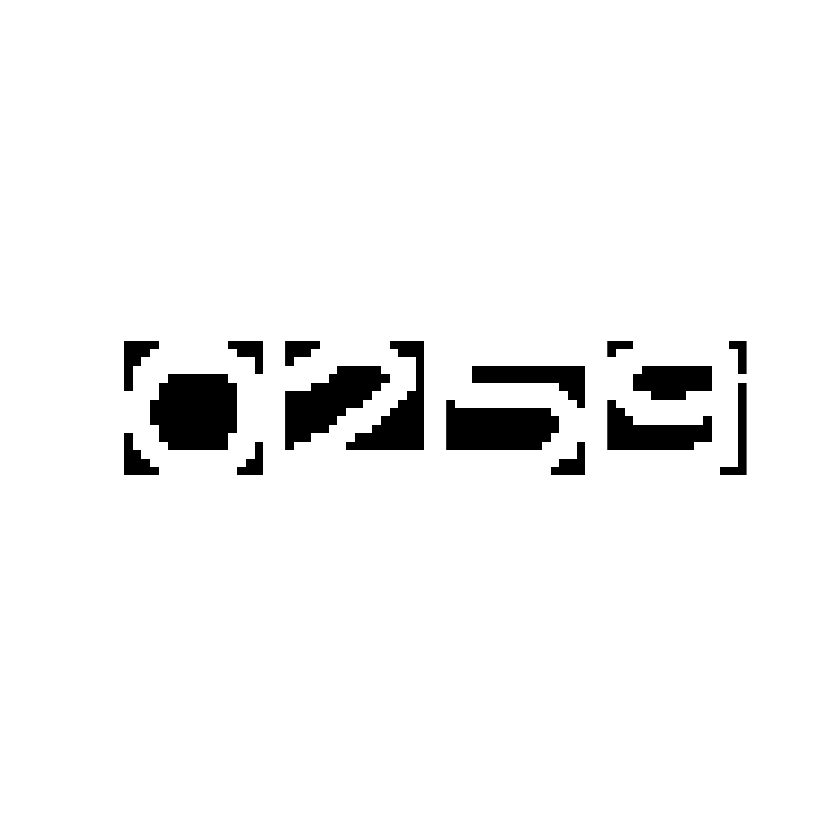

In [67]:
plota.digitos(padroes,orginal.dim)

In [68]:
# Armazena os dígitos
rede <- hopfield.armazenamento(padroes)
rede
dim(rede$pesos)

0.0000000,0.0156250,0.0078125,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,⋯,0.0000000,0.0000000,0.0078125,0.0078125,0.0078125,0.0078125,0.0078125,0.0000000,0.0000000,0.0000000
0.0156250,0.0000000,0.0078125,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,⋯,0.0000000,0.0000000,0.0078125,0.0078125,0.0078125,0.0078125,0.0078125,0.0000000,0.0000000,0.0000000
0.0078125,0.0078125,0.0000000,0.0078125,0.0078125,0.0078125,0.0078125,-0.0078125,-0.0078125,-0.0078125,⋯,-0.0078125,-0.0078125,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,-0.0078125,-0.0078125,-0.0078125
0.0000000,0.0000000,0.0078125,0.0000000,0.0156250,0.0156250,0.0000000,-0.0156250,-0.0156250,-0.0156250,⋯,-0.0156250,-0.0156250,-0.0078125,-0.0078125,-0.0078125,-0.0078125,-0.0078125,0.0000000,0.0000000,0.0000000
0.0000000,0.0000000,0.0078125,0.0156250,0.0000000,0.0156250,0.0000000,-0.0156250,-0.0156250,-0.0156250,⋯,-0.0156250,-0.0156250,-0.0078125,-0.0078125,-0.0078125,-0.0078125,-0.0078125,0.0000000,0.0000000,0.0000000
0.0000000,0.0000000,0.0078125,0.0156250,0.0156250,0.0000000,0.0000000,-0.0156250,-0.0156250,-0.0156250,⋯,-0.0156250,-0.0156250,-0.0078125,-0.0078125,-0.0078125,-0.0078125,-0.0078125,0.0000000,0.0000000,0.0000000
0.0000000,0.0000000,0.0078125,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,⋯,0.0000000,0.0000000,0.0078125,0.0078125,0.0078125,0.0078125,-0.0078125,-0.0156250,-0.0156250,-0.0156250
0.0000000,0.0000000,-0.0078125,-0.0156250,-0.0156250,-0.0156250,0.0000000,0.0000000,0.0156250,0.0156250,⋯,0.0156250,0.0156250,0.0078125,0.0078125,0.0078125,0.0078125,0.0078125,0.0000000,0.0000000,0.0000000
0.0000000,0.0000000,-0.0078125,-0.0156250,-0.0156250,-0.0156250,0.0000000,0.0156250,0.0000000,0.0156250,⋯,0.0156250,0.0156250,0.0078125,0.0078125,0.0078125,0.0078125,0.0078125,0.0000000,0.0000000,0.0000000
0.0000000,0.0000000,-0.0078125,-0.0156250,-0.0156250,-0.0156250,0.0000000,0.0156250,0.0156250,0.0000000,⋯,0.0156250,0.0156250,0.0078125,0.0078125,0.0078125,0.0078125,0.0078125,0.0000000,0.0000000,0.0000000
0.0000000,0.0000000,-0.0078125,-0.0156250,-0.0156250,-0.0156250,0.0000000,0.0156250,0.0156250,0.0156250,⋯,0.0156250,0.0156250,0.0078125,0.0078125,0.0078125,0.0078125,0.0078125,0.0000000,0.0000000,0.0000000


[1] 256 256

In [69]:
#dimesao da matriz de pesos da rede
dim(rede$pesos)[1]

[1] 256

In [70]:
img <- readPNG(paste("./Digitos/",'3','.png',sep='')) # Le as imagens
orginal.dim <<- dim(img) # Armazena as dimensoes originais
orginal.dim

[1] 16 16

Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 768 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 512 


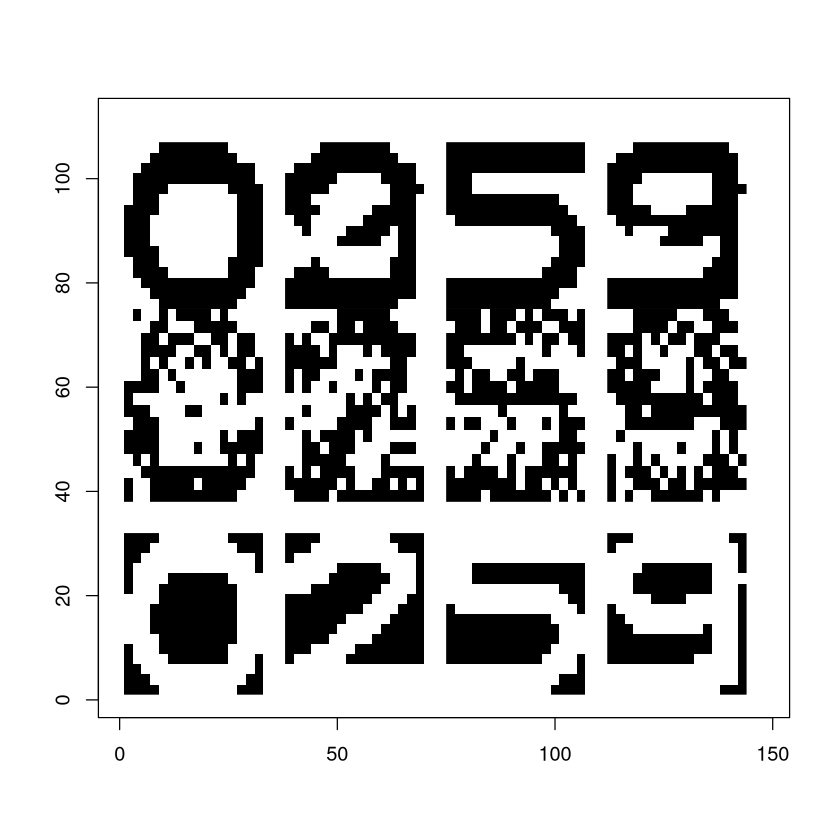

In [71]:
# Recupera padroes
digitos <- c(0,2,5,9)
testa.digitos(rede,digitos,padroes,0.8)

**Importante**: As Redes de Hopfield tradicionais sofrem muita interferência (chamada de crosstalk) quando os padrões não são ortogonais. Como os dígitos podem ter muitos pixels pretos em comum nas bordas e sobreposições nos traços, a rede pode acabar misturando os dígitos se você tentar armazenar muitos de uma vez.

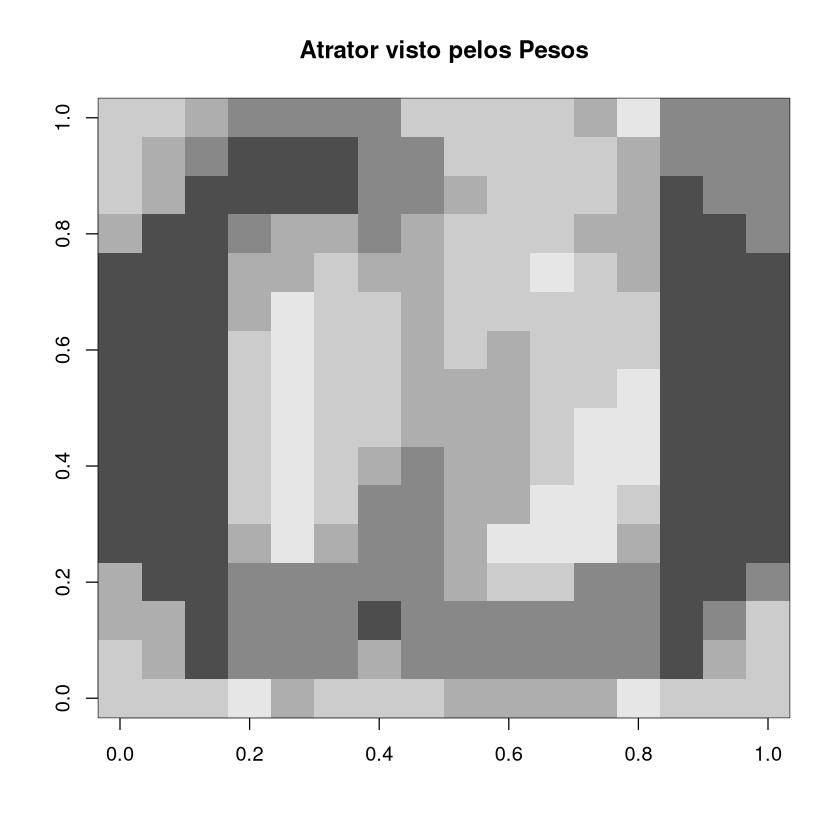

In [72]:
# 1. Escolha um índice de pixel que você sabe que é central
pixel_index <- 12

# 2. Extraia a linha correspondente a esse neurônio
weights_vector <- rede$pesos[pixel_index, ]

# 3. Transforme em matriz 16x16
im_weights <- matrix(weights_vector, nrow = 16, byrow = TRUE)

# 4. Plote para ver o "atrator" escondido nos pesos
image(t(apply(im_weights, 2, rev)), col = gray.colors(255), main = "Atrator visto pelos Pesos")

In [74]:
# Analisar a similaridade entre as imagens - Cosseno
analisa.imagens <- function(){

	digits = c(1,2,3,4,5,6,7,8,9,0)
	patterns <- list()
	orginal.dim <- NULL

	for (i in digits) {
		img <- readPNG(paste("Digitos/",as.character(i),'.png',sep=''))
		orginal.dim <- dim(img)
		dim(img) <- NULL
		img <- img*2 - 1
		patterns[[length(patterns)+1]] <- c(img,1)	# the last 1 for bias
	}

	similar = matrix(rep(0,length(digits) * length(digits)),
	                 length(digits), length(digits))
	for (i in 1:length(patterns)) {
		for (j in 1:length(patterns)) {
			# Similaridade cosseno
			similar[i,j] = patterns[[i]] %*% patterns[[j]] /
			  (sqrt(sum(patterns[[i]] ^ 2)) * sqrt(sum(patterns[[j]] ^ 2)))
		}
	}

	print("Similaridade entre imagens (cosseno)")
	print(similar)
}

In [75]:
analisa.imagens()

[1] "Similaridade entre imagens (cosseno)"
             [,1]         [,2]        [,3]        [,4]        [,5]         [,6]
 [1,]  1.00000000 -0.073929961 -0.04280156  0.07392996  0.01945525  0.066147860
 [2,] -0.07392996  1.000000000  0.45525292 -0.19066148  0.14396887  0.003891051
 [3,] -0.04280156  0.455252918  1.00000000 -0.28404669  0.28404669  0.175097276
 [4,]  0.07392996 -0.190661479 -0.28404669  1.00000000 -0.28404669  0.291828794
 [5,]  0.01945525  0.143968872  0.28404669 -0.28404669  1.00000000  0.081712062
 [6,]  0.06614786  0.003891051  0.17509728  0.29182879  0.08171206  1.000000000
 [7,]  0.01167315  0.136186770  0.26070039  0.08171206  0.16731518 -0.175097276
 [8,]  0.01945525  0.408560311  0.42412451 -0.12840467  0.45525292  0.284046693
 [9,]  0.01945525  0.392996109  0.47081712 -0.15953307  0.53307393  0.190661479
[10,]  0.05836576  0.245136187  0.44747082 -0.02723735  0.19844358  0.260700389
             [,7]        [,8]        [,9]       [,10]
 [1,]  0.01167315  0.01

[1]   4 256


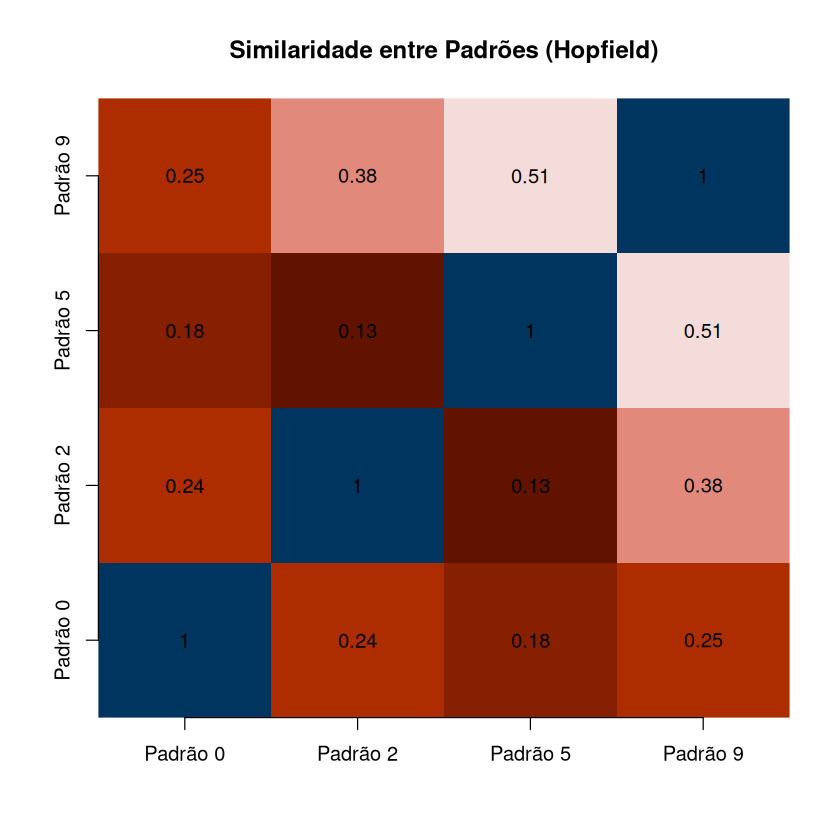

In [76]:
# Similaridade entre as imagens: pearson

# 1. Converte a lista para matriz (cada linha = um número)
matriz_padroes <- do.call(rbind, padroes)

# 2. Função para calcular a similaridade (Produto Escalar Normalizado)
# Isso equivale à correlação entre os vetores
matriz_sim <- cor(t(matriz_padroes))

# 3. Verifica as dimensões
print(dim(matriz_padroes))

# 4. Renomear para facilitar a leitura (ex: Número 1, Número 2...)
rownames(matriz_sim) <- paste("Padrão", digitos[1:dim(matriz_padroes)[1]])
colnames(matriz_sim) <- paste("Padrão", digitos[1:dim(matriz_padroes)[1]])

# 5. Visualizar com um Heatmap
# Vamos usar cores de Azul (opostos) a Vermelho (iguais)
image(1:dim(matriz_padroes)[1], 1:dim(matriz_padroes)[1], matriz_sim,
      col = hcl.colors(20, "RdBu"),
      main = "Similaridade entre Padrões (Hopfield)",
      xlab = "", ylab = "", axes = FALSE)

# Adicionar os valores e eixos
axis(1, at=1:dim(matriz_padroes)[1], labels=rownames(matriz_sim))
axis(2, at=1:dim(matriz_padroes)[1], labels=colnames(matriz_sim))
text(expand.grid(1:dim(matriz_padroes)[1], 1:dim(matriz_padroes)[1]), labels = round(c(matriz_sim), 2))


**Experimento da Função de Energia**

Esta função calcula "quão estável" a rede está. Você verá que o valor para a imagem original e para a invertida será o mesmo.

In [78]:
# Função para calcular a energia do estado atual (y)
# E = -0.5 * y %*% W %*% y
calcular_energia <- function(y, W) {
  energia <- -0.5 * (t(y) %*% W %*% y)
  return(as.numeric(energia))
}

# Teste de simetria:
energia_orig <- calcular_energia(padroes[[4]], rede$pesos)
energia_inv  <- calcular_energia(-padroes[[4]], rede$pesos)
print(paste("Energia Original:", energia_orig))
print(paste("Energia Inversa:", energia_inv))

[1] "Energia Original: -190.1640625"
[1] "Energia Inversa: -190.1640625"


**Experimento da Bacia de Atração**

Este código automatiza o teste de ruído (de 0% a 100%) e plota o gráfico que mostra a rede "pulando" para o atrator inverso após os 50%.

In [79]:
seq(0, 1, by = 0.05)

[1] 0.00 0.05 0.10 0.15 0.20 0.25 0.30 0.35 0.40 0.45 0.50 0.55 0.60 0.65 0.70
[16] 0.75 0.80 0.85 0.90 0.95 1.00

Alcancou estado estavel na iteração 256 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 768 
Alcancou estado estavel na iteração 768 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 1024 
Alcancou estado estavel na iteração 768 
Alcancou estado estavel na iteração 768 
Alcancou estado estavel na iteração 768 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 768 
Alcancou estado estavel na iteração 512 
Alcancou estado estavel na iteração 256 


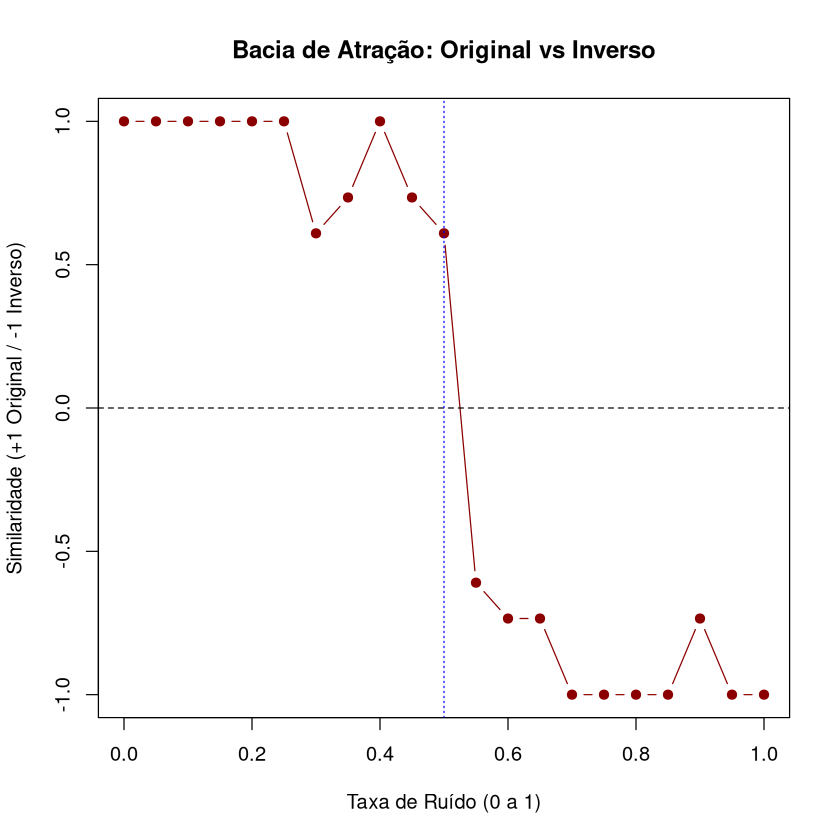

In [80]:
# Função para adicionar ruído (inverter pixels)
add_ruido <- function(imagem, taxa) {
  n <- length(imagem)
  indices <- sample(1:n, floor(n * taxa))
  imagem[indices] <- imagem[indices] * -1
  return(imagem)
}

# Parâmetros do experimento
taxas_ruido <- seq(0, 1, by = 0.05)
similaridades <- c()

# Escolha um padrão do seu conjunto
p_orig <- padroes[[3]]
W <- rede$pesos

for(r in taxas_ruido) {
  # 1. Suja a imagem
  img_suja <- add_ruido(p_orig, r)

  # 2. Recupera a imagem
  img_rec <- hopfiel.rec(rede, img_suja, maxit = 256 * 15)

  # 3. Calcula similaridade (Produto Escalar Normalizado)
  # +1 significa que voltou ao original, -1 significa que foi para o inverso
  sim <- sum(p_orig * img_rec) / length(p_orig)
  similaridades <- c(similaridades, sim)
}

# Plotando o resultado
plot(taxas_ruido, similaridades, type="b", pch=19, col="darkred",
     main="Bacia de Atração: Original vs Inverso",
     xlab="Taxa de Ruído (0 a 1)",
     ylab="Similaridade (+1 Original / -1 Inverso)")
abline(h=0, lty=2)
abline(v=0.5, col="blue", lty=3)

**Representação visual (gráfica) de um "poço de energia"**

Superfície de energia como um relevo onde a "bola" (o estado da rede) busca o ponto mais baixo.

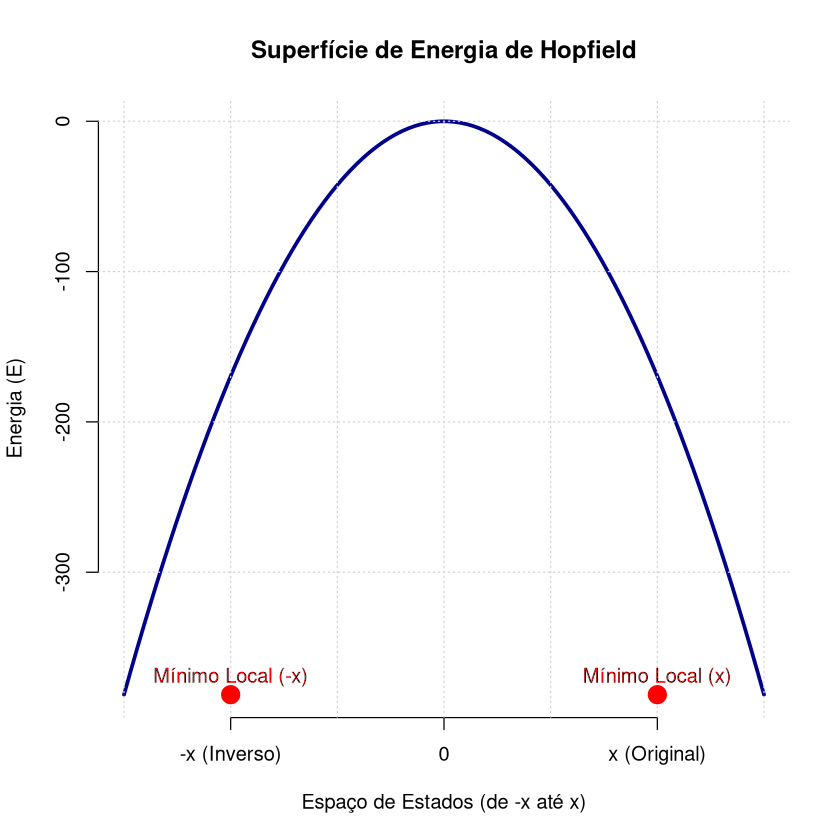

In [81]:
# Criando uma visualização da "Ladeira de Energia"
# Vamos projetar a energia em uma linha que vai do Inverso (-x) ao Original (x)

p_orig <- padroes[[3]] # Seu padrão 'x'
W <- rede$pesos

# Criamos uma sequência que interpola entre -x e +x
alfa <- seq(-1.5, 1.5, length.out = 100)
energias <- sapply(alfa, function(a) {
  # Estado intermediário 'x_mistura'
  x_temp <- a * p_orig
  # Calculando E = -0.5 * x.T * W * x
  return(-0.5 * as.numeric(t(x_temp) %*% W %*% x_temp))
})

# Plotando o Poço de Energia
plot(alfa, energias, type = "l", lwd = 3, col = "darkblue",
     main = "Superfície de Energia de Hopfield",
     xlab = "Espaço de Estados (de -x até x)",
     ylab = "Energia (E)",
     axes = FALSE)
axis(1, at = c(-1, 0, 1), labels = c("-x (Inverso)", "0", "x (Original)"))
axis(2)
grid()

# Destacando os pontos de equilíbrio
points(c(-1, 1), c(min(energias), min(energias)), col = "red", pch = 19, cex = 2)
text(1, min(energias), "Mínimo Local (x)", pos = 3, col = "red")
text(-1, min(energias), "Mínimo Local (-x)", pos = 3, col = "red")

A superfície de energia de uma Rede de Hopfield é simétrica. Isso significa que, ao treinar a rede para reconhecer o padrão de um "número", criamos um poço de estabilidade para ele ($x$) e, obrigatoriamente, um poço idêntico para o seu negativo ($-x$). O ruído atua como um empurrão: se for superior a 50%, a configuração inicial cruza a barreira de decisão e cai no atrator invertido.

In [82]:
energias

[1] -381.46289062 -366.20593183 -351.26033955 -336.62611377 -322.30325449
  [6] -308.29176172 -294.59163546 -281.20287570 -268.12548245 -255.35945571
 [11] -242.90479547 -230.76150174 -218.92957451 -207.40901379 -196.19981957
 [16] -185.30199186 -174.71553066 -164.44043596 -154.47670777 -144.82434609
 [21] -135.48335091 -126.45372224 -117.73546007 -109.32856441 -101.23303525
 [26]  -93.44887260  -85.97607646  -78.81464682  -71.96458369  -65.42588707
 [31]  -59.19855695  -53.28259333  -47.67799623  -42.38476562  -37.40290153
 [36]  -32.73240394  -28.37327286  -24.32550828  -20.58911021  -17.16407864
 [41]  -14.05041358  -11.24811503   -8.75718298   -6.57761744   -4.70941840
 [46]   -3.15258587   -1.90711985   -0.97302033   -0.35028732   -0.03892081
 [51]   -0.03892081   -0.35028732   -0.97302033   -1.90711985   -3.15258587
 [56]   -4.70941840   -6.57761744   -8.75718298  -11.24811503  -14.05041358
 [61]  -17.16407864  -20.58911021  -24.32550828  -28.37327286  -32.73240394
 [66]  -37.40290153  -42.38476562  -47.67799623  -53.28259333  -59.19855695
 [71]  -65.42588707  -71.96458369  -78.81464682  -85.97607646  -93.44887260
 [76] -101.23303525 -109.32856441 -117.73546007 -126.45372224 -135.48335091
 [81] -144.82434609 -154.47670777 -164.44043596 -174.71553066 -185.30199186
 [86] -196.19981957 -207.40901379 -218.92957451 -230.76150174 -242.90479547
 [91] -255.35945571 -268.12548245 -281.20287570 -294.59163546 -308.29176172
 [96] -322.30325449 -336.62611377 -351.26033955 -366.20593183 -381.46289062